Punto 1: Optimal timestep (SHARP)

In [ ]:
import numpy as np
import os 
import time as a_time 
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_sharp
from m_force import calc_force_sharp
from m_vel import calc_vel

def run_md_simulation(dt_sec, nMD, temp, dt_fs_str, results_dir, myseed=16324478):
    """
    Esegue una singola simulazione NVE per un dato timestep.
    Salva i risultati nella cartella specificata.
    """
    
    np.random.seed(myseed)
    
    # --- Parametri Costanti ---
    filename = "fcc100a256.txt"
    epsilon = 0.345
    sigma = 2.644
    cutoff = 4.5
    k_B = 1 / 11603
    mass = 108 * 1.66*10**(-27) / 16
    cc = np.sqrt(3 * k_B * temp / mass)

    # --- Nome file di output dinamico ---
    # <-- MODIFICA 4: Costruisce il percorso completo del file

    base_filename = f'Risultati_MD_sharp_{temp}K_{dt_fs_str}fs_{nMD}step.dat'
    outputname1 = os.path.join(results_dir, base_filename)

    # --- Inizializzazione ---
    pos, natoms = read_pos(filename)
    nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
    force = calc_force_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
    E_pot_in = calc_epot_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
    
    vel, _ = calc_vel(cc, natoms, myseed, temp)
    E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))
    
    print(f"  Inizializzazione per dt={dt_fs_str}fs... E_tot: {E_pot_in + E_kin_in:.4f}")

    force_new = np.zeros((natoms, 3))
    
    with open(outputname1, "w") as file1:
        file1.write("# Step \t Temp \t E_pot \t E_kin \t E_tot \n")

        for iMD in range(1, nMD + 1):
            # Algoritmo di Verlet... (invariato)
            for i in range(0, natoms):
                pos[i,0] += vel[i,0] * dt_sec + 0.5 * (force[i,0] / mass) * dt_sec**2
                pos[i,1] += vel[i,1] * dt_sec + 0.5 * (force[i,1] / mass) * dt_sec**2
                pos[i,2] += vel[i,2] * dt_sec + 0.5 * (force[i,2] / mass) * dt_sec**2

            nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
            force_new = calc_force_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
            E_pot = calc_epot_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)

            E_kin = 0.0
            for i in range(0, natoms):
                vel[i,0] += 0.5 * (force[i,0] + force_new[i,0]) / mass * dt_sec
                vel[i,1] += 0.5 * (force[i,1] + force_new[i,1]) / mass * dt_sec
                vel[i,2] += 0.5 * (force[i,2] + force_new[i,2]) / mass * dt_sec
                E_kin += 0.5 * mass * (vel[i,0]**2 + vel[i,1]**2 + vel[i,2]**2)

            force = force_new
            temp_calc = 2/3 * E_kin / (natoms * k_B)
            E_tot = E_pot + E_kin

            file1.write(f"{iMD} \t {temp_calc} \t {E_pot} \t {E_kin} \t {E_tot} \n")

    print(f"  Simulazione dt={dt_fs_str}fs completata. File salvato: {outputname1}")

# --- Blocco di Esecuzione Principale ---
if __name__ == "__main__":
    
    # --- Parametri Globali ---
    TEMP_K = 50       
    N_STEPS = 5000     
    FS_TO_SEC = 1e-15 
    
    # <-- MODIFICA 2: Definiamo la cartella dei risultati
    RESULTS_DIR = os.path.join("Esercizio 1","Risultati") 
    
    # Intervallo di timestep da testare (in femtosecondi)
    timestep_range_fs = range(1, 26, 1) 

    # <-- MODIFICA 3: Creiamo la cartella se non esiste
    os.makedirs(RESULTS_DIR, exist_ok=True)

    print("===== AVVIO CICLO DI SIMULAZIONI MD =====")
    print(f"Temperatura: {TEMP_K} K, Step per simulazione: {N_STEPS}")
    print(f"Cartella di output: {RESULTS_DIR}")
    print("---------------------------------------------")
    
    start_total_time = a_time.time()
    
    for dt_fs in timestep_range_fs:
        start_loop_time = a_time.time()
        
        dt_s = dt_fs * FS_TO_SEC
        dt_str = str(dt_fs).zfill(2)
        
        print(f"--- Esecuzione simulazione per dt = {dt_fs} fs ---")
        
        # Passiamo la cartella dei risultati alla funzione
        run_md_simulation(dt_sec=dt_s, nMD=N_STEPS, temp=TEMP_K, 
                            dt_fs_str=dt_str, results_dir=RESULTS_DIR, myseed=16324478)
        
        loop_time = a_time.time() - start_loop_time
        print(f"  Tempo di esecuzione: {loop_time:.2f} s")

    end_total_time = a_time.time()
    print("---------------------------------------------")
    print("===== TUTTE LE SIMULAZIONI COMPLETATE =====")
    print(f"Tempo totale: {(end_total_time - start_total_time):.2f} s")

Sharp cutoff ottimizzato meglio perché senza cicli

In [ ]:
import numpy as np
import os 
import time as a_time 
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_sharp
from m_force import calc_force_sharp
from m_vel import calc_vel

def run_md_simulation(dt_sec, nMD, temp, dt_fs_str, results_dir, myseed=16324478):
    """
    Esegue una singola simulazione NVE per un dato timestep.
    Salva i risultati nella cartella specificata.
    """
    
    np.random.seed(myseed)
    
    # --- Parametri Costanti ---
    filename = "fcc100a256.txt"
    epsilon = 0.345
    sigma = 2.644
    cutoff = 4.5
    k_B = 1 / 11603
    mass = 108 * 1.66*10**(-27) / 16
    cc = np.sqrt(3 * k_B * temp / mass)

    # --- Nome file di output dinamico ---
    # <-- MODIFICA 4: Costruisce il percorso completo del file

    base_filename = f'Risultati_MD_sharp_{temp}K_{dt_fs_str}fs_{nMD}step.dat'
    outputname1 = os.path.join(results_dir, base_filename)

    # --- Inizializzazione ---
    pos, natoms = read_pos(filename)
    nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
    force = calc_force_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
    E_pot_in = calc_epot_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
    
    vel, _ = calc_vel(cc, natoms, myseed, temp)
    E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))
    
    print(f"  Inizializzazione per dt={dt_fs_str}fs... E_tot: {E_pot_in + E_kin_in:.4f}")

    force_new = np.zeros((natoms, 3))
    
    with open(outputname1, "w") as file1:
        file1.write("# Step \t Temp \t E_pot \t E_kin \t E_tot \n")

        for iMD in range(1, nMD + 1):
            # Algoritmo di Verlet... (invariato)
            
            pos += vel * dt_sec + 0.5 * (force / mass) * dt_sec**2
                

            nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
            force_new = calc_force_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)
            E_pot = calc_epot_sharp(natoms, pos, epsilon, sigma, nnbrs, whichnbr)

            E_kin = 0.0
            
            vel += 0.5 * (force + force_new) / mass * dt_sec
                
            E_kin += 0.5 * mass * (vel**2 + vel**2 + vel**2)

            force = force_new
            temp_calc = 2/3 * E_kin / (natoms * k_B)
            E_tot = E_pot + E_kin

            file1.write(f"{iMD} \t {temp_calc} \t {E_pot} \t {E_kin} \t {E_tot} \n")

    print(f"  Simulazione dt={dt_fs_str}fs completata. File salvato: {outputname1}")

# --- Blocco di Esecuzione Principale ---
if __name__ == "__main__":
    
    # --- Parametri Globali ---
    TEMP_K = 50       
    N_STEPS = 5000     
    FS_TO_SEC = 1e-15 
    
    # <-- MODIFICA 2: Definiamo la cartella dei risultati
    RESULTS_DIR = os.path.join("Esercizio 1","Risultati") 
    
    # Intervallo di timestep da testare (in femtosecondi)
    timestep_range_fs = range(1, 26, 1) 

    # <-- MODIFICA 3: Creiamo la cartella se non esiste
    os.makedirs(RESULTS_DIR, exist_ok=True)

    print("===== AVVIO CICLO DI SIMULAZIONI MD =====")
    print(f"Temperatura: {TEMP_K} K, Step per simulazione: {N_STEPS}")
    print(f"Cartella di output: {RESULTS_DIR}")
    print("---------------------------------------------")
    
    start_total_time = a_time.time()
    
    for dt_fs in timestep_range_fs:
        start_loop_time = a_time.time()
        
        dt_s = dt_fs * FS_TO_SEC
        dt_str = str(dt_fs).zfill(2)
        
        print(f"--- Esecuzione simulazione per dt = {dt_fs} fs ---")
        
        # Passiamo la cartella dei risultati alla funzione
        run_md_simulation(dt_sec=dt_s, nMD=N_STEPS, temp=TEMP_K, 
                            dt_fs_str=dt_str, results_dir=RESULTS_DIR, myseed=16324478)
        
        loop_time = a_time.time() - start_loop_time
        print(f"  Tempo di esecuzione: {loop_time:.2f} s")

    end_total_time = a_time.time()
    print("---------------------------------------------")
    print("===== TUTTE LE SIMULAZIONI COMPLETATE =====")
    print(f"Tempo totale: {(end_total_time - start_total_time):.2f} s")

Plot optimal timestep SHARP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os 
def calculate_fluctuation(filename):
    """
    Calcola la fluttuazione relativa dell'energia (std(E)/mean(E))
    da un file di risultati.
    """
    try:
        data = np.loadtxt(filename, comments="#")
        
        if data.ndim == 1 or len(data) == 0:
            print(f"    Attenzione: file {filename} corrotto o vuoto.")
            return np.nan 

        #Etot = data[:, 4] 
        #n_steps = len(Etot)
        #skip_steps = int(n_steps * skip_fraction)
        
        dt = 1 * 10**(-15)
        step = data[:,0]
        time = step * dt
        time_end = time[-1]
        thTIME = 3*10**(-12)

       # temp = data[:,1]
       # Epot = data[:,2]
       # Ekin = data[:,3]
        Etot = data[:,4]

        n = 0
        avgE = 0
        E2 = 0

        for i in range(0,len(step)):
            t = i * dt

            if(t > thTIME):
                n += 1
                avgE += Etot[i]
                E2 += Etot[i]**2

        avgE = avgE / n
        E2 = E2 / n
        deltaE = np.sqrt(E2 - avgE**2)
        print(deltaE / avgE)
        fluctuation = deltaE / np.abs(avgE)
        
        return fluctuation

    except Exception as e:
        print(f"    Errore durante l'analisi di {filename}: {e}")
        return np.nan 

# --- Blocco di Esecuzione Principale ---
if __name__ == "__main__":

    # --- Parametri (devono corrispondere a Script 1) ---
    TEMP_K = [50, 500]
    N_STEPS = 5000
    timestep_range_fs = range(1, 26, 1)
    
    # <-- MODIFICA 2: Definiamo la cartella dei risultati
    RESULTS_DIR = os.path.join("Esercizio 1", "Risultati")

    
    print("===== AVVIO ANALISI RISULTATI =====")
    print(f"Lettura da cartella: {RESULTS_DIR}")

    for t in TEMP_K:
        results_dt = []
        results_fluctuation = []

        for dt_fs in timestep_range_fs:
            dt_str = str(dt_fs).zfill(2)
            
            # <-- MODIFICA 3: Ricostruiamo il percorso completo del file da leggere
            base_filename = f'Risultati_MD_sharp_{t}K_{dt_str}fs_{N_STEPS}step.dat'
            filename = os.path.join(RESULTS_DIR, base_filename)

            print(f"Analisi file: {filename}")
            
            if os.path.exists(filename):
                fluct = calculate_fluctuation(filename)
                
                if not np.isnan(fluct):
                    results_dt.append(dt_fs)
                    results_fluctuation.append(fluct)
                    print(f"  -> dt = {dt_fs} fs, Fluttuazione = {fluct:.4e}")
                else:
                    print(f"  -> Calcolo fallito per dt = {dt_fs} fs (simulazione instabile?)")
            else:
                print(f"  -> File non trovato. Saltato.")

        print("===== ANALISI COMPLETATA. CREAZIONE GRAFICO. =====")

        # --- Creazione del Grafico ---
        #plt.figure(figsize=(10, 6))
        
        plt.plot(results_dt, results_fluctuation, 'o-', linewidth=2, markersize=5, label=f'{t} K')




    plt.title('Optimal Timestep (sharp cutoff)', fontsize=16)
    plt.xlabel('Timestep $dt$ (fs)', fontsize=14)
    plt.ylabel('$\delta E / | \langle E \\rangle |$', fontsize=14)
    
    plt.yscale('log')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    plt.axhline(y=1e-5, color='red', linestyle=':')

    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    
    # <-- MODIFICA 4: Salviamo il grafico nella cartella dei risultati
    
    #output_plot = os.path.join(RESULTS_DIR, 'optimal_timestep_plot.png')
    #plt.savefig(output_plot)
    #print(f"Grafico salvato come: {output_plot}")
    #plt.show()


Plot variabili con legenda

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename = f'Risultati_MD_sharp_50K_19fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 19 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)

print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


Plot variabili a diversa temperatura sovrapposte

--- 50K (dt: 19 fs) ---
Fluct. relativa Etot: 8.45e-06
--- 500K (dt: 6 fs) ---
Fluct. relativa Etot: 7.84e-06
--- 1000K (dt: 4 fs) ---
Fluct. relativa Etot: nan
--- 2000K (dt: 2 fs) ---
Fluct. relativa Etot: nan


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar

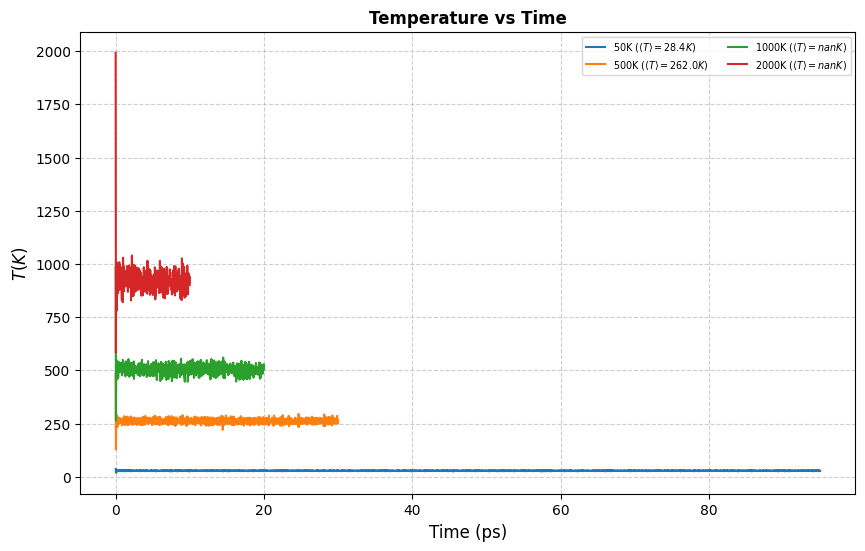

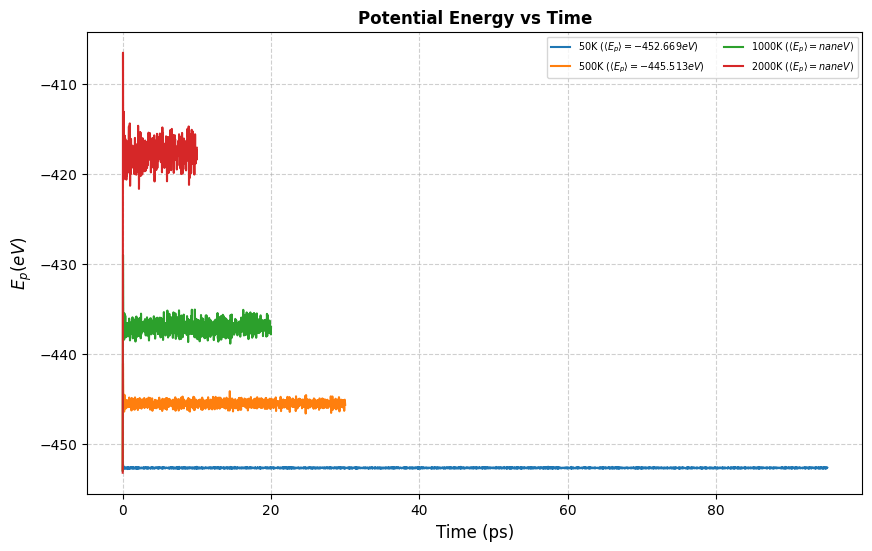

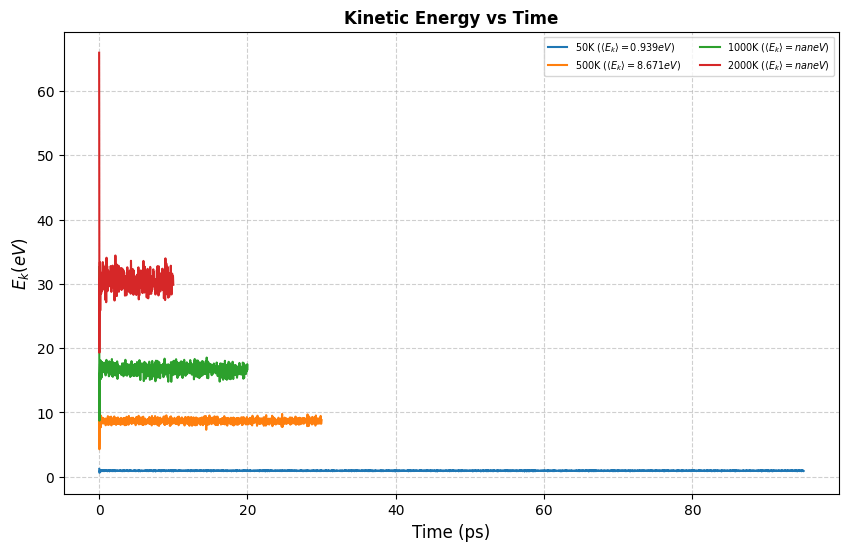

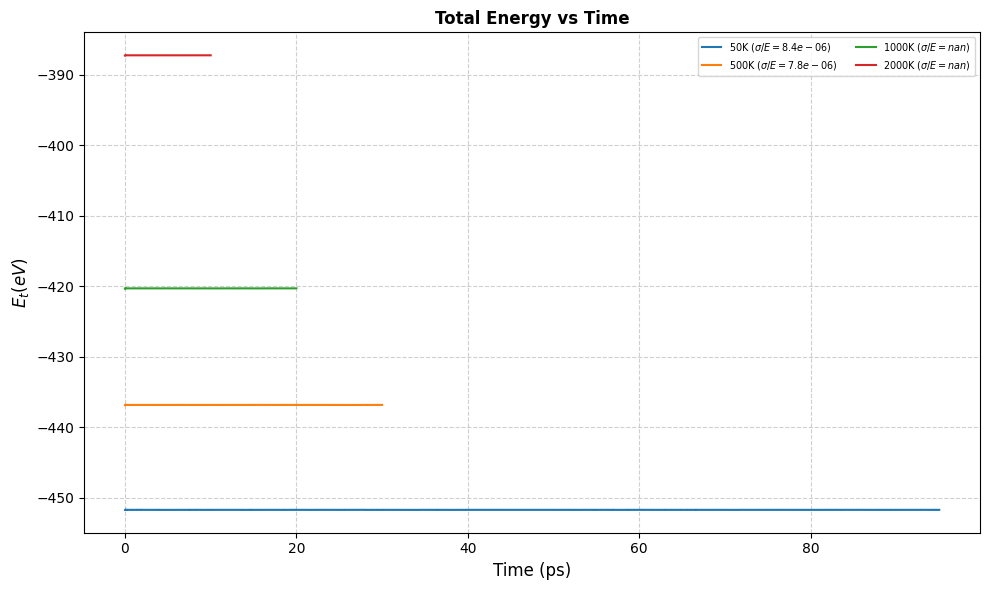

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Dizionario che mappa la temperatura al timestep (in fs)
# Nota: uso le stringhe per i nomi dei file e i float per i calcoli
temp_to_dt = {
    "50K": 19,
    "500K": 6,
    "1000K": 4,
    "2000K": 2
}

results_dir = os.path.join("Esercizio 1", "Risultati")
thTIME_fs = 3000  # 3 ps in femtosecondi per coerenza

# Inizializzazione delle 4 figure
fig_t, ax_t = plt.subplots(figsize=(10, 6))
fig_ep, ax_ep = plt.subplots(figsize=(10, 6))
fig_ek, ax_ek = plt.subplots(figsize=(10, 6))
fig_et, ax_et = plt.subplots(figsize=(10, 6))

for temp_val, dt_fs in temp_to_dt.items():
    # Trasformiamo il timestep in secondi per i calcoli fisici
    dt = dt_fs * 1e-15
    thTIME = thTIME_fs * 1e-15
    
    # Costruzione dinamica del nome file (es: ..._06fs_...)
    # Usiamo :02d per assicurarci che 6 diventi '06' come nel tuo schema
    base_filename = f'Risultati_MD_poly_{temp_val}_{dt_fs:02d}fs_5000step.dat'
    filename = os.path.join(results_dir, base_filename)
    
    if not os.path.exists(filename):
        print(f"File non trovato: {filename}")
        continue
        
    data = np.loadtxt(filename)
    
    step = data[:, 0]
    time = step * dt
    temp_data = data[:, 1]
    Epot = data[:, 2]
    Ekin = data[:, 3]
    Etot = data[:, 4]

    # Calcolo medie e fluttuazioni dopo il tempo di termalizzazione
    mask = time > thTIME
    
    avgT, deltaT = np.mean(temp_data[mask]), np.std(temp_data[mask])
    avgE_pot, deltaE_pot = np.mean(Epot[mask]), np.std(Epot[mask])
    avgE_kin, deltaE_kin = np.mean(Ekin[mask]), np.std(Ekin[mask])
    avgE_tot, deltaE_tot = np.mean(Etot[mask]), np.std(Etot[mask])

    print(f"--- {temp_val} (dt: {dt_fs} fs) ---")
    print(f"Fluct. relativa Etot: {deltaE_tot / abs(avgE_tot):.2e}")

    # Plot (usiamo l'asse dei tempi in picosecondi o secondi)
    # Nota: moltiplico per 1e12 per vedere l'asse x in ps, più leggibile
    t_plot = time * 1e12 
    
    ax_t.plot(t_plot, temp_data, label=f'{temp_val} ($\\langle T \\rangle={avgT:.1f} K$)')
    ax_ep.plot(t_plot, Epot, label=f'{temp_val} ($\\langle E_p \\rangle={avgE_pot:.3f} eV$)')
    ax_ek.plot(t_plot, Ekin, label=f'{temp_val} ($\\langle E_k \\rangle={avgE_kin:.3f} eV$)')
    ax_et.plot(t_plot, Etot, label=f'{temp_val} ($\\sigma/E={deltaE_tot/abs(avgE_tot):.1e}$)')

# Formattazione finale
titles = ["Temperature vs Time", "Potential Energy vs Time", "Kinetic Energy vs Time", "Total Energy vs Time"]
ylabels = ["$T (K)$", "$E_p (eV)$", "$E_k (eV)$", "$E_t (eV)$"]
axes = [ax_t, ax_ep, ax_ek, ax_et]

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel('Time (ps)', fontsize=12)
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.legend(loc='best', fontsize='x-small', ncol=2)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Punto 2: Optimal timestep (POLY)

In [ ]:
import numpy as np
import os 
import time as a_time 
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_pol
from m_force import calc_force_pol
from m_vel import calc_vel
from poly7 import poly7 


def run_md_simulation(dt_sec, nMD, temp, dt_fs_str, results_dir, myseed=16324478):
    """
    Esegue una singola simulazione NVE per un dato timestep.
    Salva i risultati nella cartella specificata.
    """
    
    np.random.seed(myseed)
    
    # --- Parametri Costanti ---
    filename = "fcc100a256.txt"
    epsilon = 0.345
    sigma = 2.644
    cutoff = 4.5
    rpoly = 4.2
    k_B = 1 / 11603
    mass = 108 * 1.66*10**(-27) / 16
    cc = np.sqrt(3 * k_B * temp / mass)

    # --- Nome file di output dinamico ---
    # <-- MODIFICA 4: Costruisce il percorso completo del file

    base_filename = f'Risultati_MD_poly_{temp}K_{dt_fs_str}fs_{nMD}step.dat'
    outputname1 = os.path.join(results_dir, base_filename)

    # --- Inizializzazione ---
    LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
    pos, natoms = read_pos(filename)
    nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
    force = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)
    E_pot_in = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,LJpoly.A,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)

    vel, _ = calc_vel(cc, natoms, myseed, temp)
    E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))
    
    print(f"  Inizializzazione per dt={dt_fs_str}fs... E_tot: {E_pot_in + E_kin_in:.4f}")

    force_new = np.zeros((natoms, 3))
    
    with open(outputname1, "w") as file1:
        file1.write("# Step \t Temp \t E_pot \t E_kin \t E_tot \n")

        for iMD in range(1, nMD + 1):
            # Algoritmo di Verlet... (invariato)
            for i in range(0, natoms):
                pos[i,0] += vel[i,0] * dt_sec + 0.5 * (force[i,0] / mass) * dt_sec**2
                pos[i,1] += vel[i,1] * dt_sec + 0.5 * (force[i,1] / mass) * dt_sec**2
                pos[i,2] += vel[i,2] * dt_sec + 0.5 * (force[i,2] / mass) * dt_sec**2

            nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
            force_new = calc_force_pol(natoms, pos, epsilon, sigma, nnbrs, whichnbr,rpoly,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)
            E_pot = calc_epot_pol(natoms, pos, epsilon, sigma, nnbrs, whichnbr,rpoly,LJpoly.A,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)

            E_kin = 0.0
            for i in range(0, natoms):
                vel[i,0] += 0.5 * (force[i,0] + force_new[i,0]) / mass * dt_sec
                vel[i,1] += 0.5 * (force[i,1] + force_new[i,1]) / mass * dt_sec
                vel[i,2] += 0.5 * (force[i,2] + force_new[i,2]) / mass * dt_sec
                E_kin += 0.5 * mass * (vel[i,0]**2 + vel[i,1]**2 + vel[i,2]**2)

            force = force_new
            temp_calc = 2/3 * E_kin / (natoms * k_B)
            E_tot = E_pot + E_kin

            file1.write(f"{iMD} \t {temp_calc} \t {E_pot} \t {E_kin} \t {E_tot} \n")

    print(f"  Simulazione dt={dt_fs_str}fs completata. File salvato: {outputname1}")

# --- Blocco di Esecuzione Principale ---
if __name__ == "__main__":
    
    # --- Parametri Globali ---
    TEMP_K = 2000       
    N_STEPS = 5000     
    FS_TO_SEC = 1e-15 
    
    # <-- MODIFICA 2: Definiamo la cartella dei risultati
    RESULTS_DIR = "Esercizio 1" 
    
    # Intervallo di timestep da testare (in femtosecondi)
    timestep_range_fs = range(1, 25, 1) 

    # <-- MODIFICA 3: Creiamo la cartella se non esiste
    os.makedirs(RESULTS_DIR, exist_ok=True)

    print("===== AVVIO CICLO DI SIMULAZIONI MD =====")
    print(f"Temperatura: {TEMP_K} K, Step per simulazione: {N_STEPS}")
    print(f"Cartella di output: {RESULTS_DIR}")
    print("---------------------------------------------")
    
    start_total_time = a_time.time()
    
    for dt_fs in timestep_range_fs:
        start_loop_time = a_time.time()
        
        dt_s = dt_fs * FS_TO_SEC
        dt_str = str(dt_fs).zfill(2)
        
        print(f"--- Esecuzione simulazione per dt = {dt_fs} fs ---")
        
        # Passiamo la cartella dei risultati alla funzione
        run_md_simulation(dt_sec=dt_s, nMD=N_STEPS, temp=TEMP_K, 
                            dt_fs_str=dt_str, results_dir=RESULTS_DIR, myseed=16324478)
        
        loop_time = a_time.time() - start_loop_time
        print(f"  Tempo di esecuzione: {loop_time:.2f} s")

    end_total_time = a_time.time()
    print("---------------------------------------------")
    print("===== TUTTE LE SIMULAZIONI COMPLETATE =====")
    print(f"Tempo totale: {(end_total_time - start_total_time):.2f} s")

Polynomial junction ottimizzato meglio perché senza cicli

In [ ]:
import numpy as np
import os 
import time as a_time 
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_pol
from m_force import calc_force_pol
from m_vel import calc_vel
from poly7 import poly7 


def run_md_simulation(dt_sec, nMD, temp, dt_fs_str, results_dir, myseed=16324478):
    """
    Esegue una singola simulazione NVE per un dato timestep.
    Salva i risultati nella cartella specificata.
    """
    
    np.random.seed(myseed)
    
    # --- Parametri Costanti ---
    filename = "fcc100a256.txt"
    epsilon = 0.345
    sigma = 2.644
    cutoff = 4.5
    rpoly = 4.2
    k_B = 1 / 11603
    mass = 108 * 1.66*10**(-27) / 16
    cc = np.sqrt(3 * k_B * temp / mass)

    # --- Nome file di output dinamico ---
    # <-- MODIFICA 4: Costruisce il percorso completo del file

    base_filename = f'Risultati_MD_poly_{temp}K_{dt_fs_str}fs_{nMD}step.dat'
    outputname1 = os.path.join(results_dir, base_filename)

    # --- Inizializzazione ---
    LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
    pos, natoms = read_pos(filename)
    nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
    force = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)
    E_pot_in = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,LJpoly.A,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)

    vel, _ = calc_vel(cc, natoms, myseed, temp)
    E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))
    
    print(f"  Inizializzazione per dt={dt_fs_str}fs... E_tot: {E_pot_in + E_kin_in:.4f}")

    force_new = np.zeros((natoms, 3))
    
    with open(outputname1, "w") as file1:
        file1.write("# Step \t Temp \t E_pot \t E_kin \t E_tot \n")

        for iMD in range(1, nMD + 1):
            # Algoritmo di Verlet... (invariato)
            pos += vel * dt_sec + 0.5 * (force / mass) * dt_sec**2
                

            nnbrs, whichnbr = calc_nbrs(natoms, pos, cutoff)
            force_new = calc_force_pol(natoms, pos, epsilon, sigma, nnbrs, whichnbr,rpoly,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)
            E_pot = calc_epot_pol(natoms, pos, epsilon, sigma, nnbrs, whichnbr,rpoly,LJpoly.A,LJpoly.B,LJpoly.C,LJpoly.D,LJpoly.E,LJpoly.F,LJpoly.G,LJpoly.H)

            E_kin = 0.0
            vel += 0.5 * (force + force_new) / mass * dt_sec
            E_kin += 0.5 * mass * (vel[i,0]**2 + vel[i,1]**2 + vel[i,2]**2)

            force = force_new
            temp_calc = 2/3 * E_kin / (natoms * k_B)
            E_tot = E_pot + E_kin

            file1.write(f"{iMD} \t {temp_calc} \t {E_pot} \t {E_kin} \t {E_tot} \n")

    print(f"  Simulazione dt={dt_fs_str}fs completata. File salvato: {outputname1}")

# --- Blocco di Esecuzione Principale ---
if __name__ == "__main__":
    
    # --- Parametri Globali ---
    TEMP_K = 2000       
    N_STEPS = 5000     
    FS_TO_SEC = 1e-15 
    
    # <-- MODIFICA 2: Definiamo la cartella dei risultati
    RESULTS_DIR = "Esercizio 1" 
    
    # Intervallo di timestep da testare (in femtosecondi)
    timestep_range_fs = range(1, 25, 1) 

    # <-- MODIFICA 3: Creiamo la cartella se non esiste
    os.makedirs(RESULTS_DIR, exist_ok=True)

    print("===== AVVIO CICLO DI SIMULAZIONI MD =====")
    print(f"Temperatura: {TEMP_K} K, Step per simulazione: {N_STEPS}")
    print(f"Cartella di output: {RESULTS_DIR}")
    print("---------------------------------------------")
    
    start_total_time = a_time.time()
    
    for dt_fs in timestep_range_fs:
        start_loop_time = a_time.time()
        
        dt_s = dt_fs * FS_TO_SEC
        dt_str = str(dt_fs).zfill(2)
        
        print(f"--- Esecuzione simulazione per dt = {dt_fs} fs ---")
        
        # Passiamo la cartella dei risultati alla funzione
        run_md_simulation(dt_sec=dt_s, nMD=N_STEPS, temp=TEMP_K, 
                            dt_fs_str=dt_str, results_dir=RESULTS_DIR, myseed=16324478)
        
        loop_time = a_time.time() - start_loop_time
        print(f"  Tempo di esecuzione: {loop_time:.2f} s")

    end_total_time = a_time.time()
    print("---------------------------------------------")
    print("===== TUTTE LE SIMULAZIONI COMPLETATE =====")
    print(f"Tempo totale: {(end_total_time - start_total_time):.2f} s")

Bonus: Polynomial junction + NO steepest descent

In [6]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_pol
from m_force import calc_force_pol
from m_vel import calc_vel
from poly7 import poly7 
from numba import jit 

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a256.txt"

epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 2000
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 2 * 10**(-15)
nMD = 5000
cc = np.sqrt(3 * k_B * temp / mass)

results_dir = os.path.join('Esercizio 1','Risultati')
results_dir2 = os.path.join('Esercizio 1','Posizioni')
#outputname1 = f'Risultati_MD_poly_{temp}K_{dt*1e15}fs_{nMD}step.dat'
base_filename1 = f'Risultati_MD_poly_NOsteepest_trajCM_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                             LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

pos,natoms = read_pos(filename)

nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
force = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
E_pot_in = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

# --- IDENTIFICAZIONE ATOMO CENTRALE ---
# 1. Trovo il CM geometrico della configurazione minimizzata
cm_initial = np.mean(pos, axis=0)

# 2. Calcolo la distanza quadra di ogni atomo dal CM
# (evito la radice quadrata sqrt per efficienza, il minimo è lo stesso)
dist_sq = np.sum((pos - cm_initial)**2, axis=1)

# 3. Trovo l'indice dell'atomo con la distanza minima
idx_central = np.argmin(dist_sq)

print(f"Centro di massa iniziale calcolato in: {cm_initial}")
print(f"L'atomo più vicino al CM è l'indice: {idx_central} (distanza: {np.sqrt(dist_sq[idx_central]):.4f} A)")

vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_CM = np.zeros((nMD,3))
traj_ver = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos += vel * dt + 0.5 * (force / mass) * dt**2
       
    traj_CM[iMD, :] = pos[idx_central, :]
    traj_ver[iMD, :] = pos[1, :]


    nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
    force_new = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
    E_pot = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

    E_kin = 0.0
    
    vel += 0.5 * (force + force_new) / mass * dt
        
    E_kin += 0.5 * mass * (vel[i,0]**2 + vel[i,1]**2 + vel[i,2]**2)

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_CM[iMD,0]} \t {traj_CM[iMD,1]} \t {traj_CM[iMD,2]} \t  {traj_ver[iMD,0]} \t {traj_ver[iMD,1]} \t {traj_ver[iMD,2]} \n")

    if(iMD % 100 == 0):
        print(iMD,temp,E_tot)
        base_filename2 = 'Posizioni poly_NOsteepest_trajCM_step ' + str(iMD) + '2000 K' '.xyz'
        outputname2 = os.path.join(results_dir2, base_filename2)
        #outputname2 = 'Posizioni lezione 10 step' + str(iMD) + '.xyz'
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close()

file1.close()




Centro di massa iniziale calcolato in: [7.2807 7.2807 7.2807]
L'atomo più vicino al CM è l'indice: 105 (distanza: 1.8015 A)
Check initial velocities:
 Temperature (T , T' , T'_check)  2000 1868.807278396285 1999.9999999999989
Initial potential energy =  -453.4501806493616
Initial kinetic energy =  66.18977850555889
Initial total energy =  -387.2604021438027

 --------------------------------------------------------------- 

100 8.81550678526448 -417.45974508025915
200 4.816252823129494 -418.47401190575397
300 3.4590285614087874 -416.41356705455087
400 1.5070343002162756 -416.57346982531675
500 1.939820607332913 -421.21114092996913
600 6.790191067628858 -418.78073183806333
700 2.8498786350095253 -417.7131488404583
800 1.7102396117289276 -417.56133407040653
900 3.3007156284672914 -418.6227235728246
1000 3.614719994268713 -417.11950846975685
1100 2.719831155246767 -421.43220008483326
1200 1.8106864387723045 -415.7719846739008
1300 1.4362143327180652 -416.37116686150597
1400 0.900851959585

Plot Polynomial variabili con legenda

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename = f'Risultati_MD_poly_2000K_02fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)

print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


Confronto sharp / Poly a 50K

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename1 = f'Risultati_MD_poly_50K_19fs_5000step.dat'
base_filename2 = f'Risultati_MD_sharp_50K_19fs_5000step.dat'
filename1 = os.path.join(results_dir, base_filename1)
filename2 = os.path.join(results_dir, base_filename2)

data_sharp = np.loadtxt(filename1)
data_poly = np.loadtxt(filename2)
dt = 19 * 10**(-15)
step_sharp = data_sharp[:,0]
step_poly = data_poly[:,0]
time_sharp = step_sharp * dt
time_poly = step_poly * dt
time_end_poly = time_poly[-1]
thTIME = 3 * 10**(-12)

temp_sharp = data_sharp[:,1]
Epot_sharp = data_sharp[:,2]
Ekin_sharp = data_sharp[:,3]
Etot_sharp = data_sharp[:,4]

temp_poly = data_poly[:,1]
Epot_poly = data_poly[:,2]
Ekin_poly = data_poly[:,3]
Etot_poly = data_poly[:,4]

n = 0
avgE_tot_sharp = 0
E2_tot_sharp = 0
avgE_pot_sharp = 0
E2_pot_sharp = 0
avgE_kin_sharp = 0
E2_kin_sharp = 0
avgT_sharp = 0
temp2_sharp = 0

avgE_tot_poly = 0
E2_tot_poly = 0
avgE_pot_poly = 0
E2_pot_poly = 0
avgE_kin_poly = 0
E2_kin_poly = 0
avgT_poly = 0
temp2_poly = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1

        avgT_sharp += temp_sharp[i]
        temp2_sharp += temp_sharp[i]**2
        avgE_pot_sharp += Epot_sharp[i]
        E2_pot_sharp += Epot_sharp[i]**2
        avgE_kin_sharp += Ekin_sharp[i]
        E2_kin_sharp += Ekin_sharp[i]**2
        avgE_tot_sharp += Etot_sharp[i]
        E2_tot_sharp += Etot_sharp[i]**2

        avgT_poly += temp_poly[i]
        temp2_poly += temp_poly[i]**2
        avgE_pot_poly += Epot_poly[i]
        E2_pot_poly += Epot_poly[i]**2
        avgE_kin_poly += Ekin_poly[i]
        E2_kin_poly += Ekin_poly[i]**2
        avgE_tot_poly += Etot_poly[i]
        E2_tot_poly += Etot_poly[i]**2

avgT_sharp = avgT_sharp / n
temp2_sharp = temp2_sharp / n
deltaT_sharp = np.sqrt(temp2_sharp - avgT_sharp**2)

avgE_pot_sharp = avgE_pot_sharp / n
E2_pot_sharp = E2_pot_sharp / n
deltaE_pot_sharp = np.sqrt(E2_pot_sharp - avgE_pot_sharp**2)

avgE_kin_sharp = avgE_kin_sharp / n
E2_kin_sharp = E2_kin_sharp / n
deltaE_kin_sharp = np.sqrt(E2_kin_sharp - avgE_kin_sharp**2)

avgE_tot_sharp = avgE_tot_sharp / n
E2_tot_sharp = E2_tot_sharp / n
deltaE_tot_sharp = np.sqrt(E2_tot_sharp - avgE_tot_sharp**2)

avgT_poly = avgT_poly / n
temp2_poly = temp2_poly / n
deltaT_poly = np.sqrt(temp2_poly - avgT_poly**2)

avgE_pot_poly = avgE_pot_poly / n
E2_pot_poly = E2_pot_poly / n
deltaE_pot_poly = np.sqrt(E2_pot_poly - avgE_pot_poly**2)

avgE_kin_poly = avgE_kin_poly / n
E2_kin_poly = E2_kin_poly / n
deltaE_kin_poly = np.sqrt(E2_kin_poly - avgE_kin_poly**2)

avgE_tot_poly = avgE_tot_poly / n
E2_tot_poly = E2_tot_poly / n
deltaE_tot_poly = np.sqrt(E2_tot_poly - avgE_tot_poly**2)


# PLOT TEMPERATURA 
label_T_sharp = f'$T(t)\\quad \\langle T^S \\rangle \\pm \\delta T \\approx {avgT_sharp:.3f}\\pm{deltaT_sharp:.3f}~\\mathrm{{K}}$'
label_T_poly = f'$T(t)\\quad \\langle T^P \\rangle \\pm \\delta T \\approx {avgT_poly:.3f}\\pm{deltaT_poly:.3f}~\\mathrm{{K}}$'
plt.plot(step_sharp*dt,temp_sharp,label=label_T_sharp, color="r")
plt.plot(step_poly*dt,temp_poly,label=label_T_poly, color="b")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep_sharp = f'$E_p(t)\\quad\\langle E_p^S\\rangle\\pm\\delta E_p \\approx {avgE_pot_sharp:.3f}\\pm{deltaE_pot_sharp:.3f}~\\mathrm{{eV}}$'
label_Ep_poly = f'$E_p(t)\\quad\\langle E_p^P\\rangle\\pm\\delta E_p \\approx {avgE_pot_poly:.3f}\\pm{deltaE_pot_poly:.3f}~\\mathrm{{eV}}$'
plt.plot(step_sharp*dt, Epot_sharp, label=label_Ep_sharp, color="r")
plt.plot(step_poly*dt, Epot_poly, label=label_Ep_poly, color="b")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek_sharp = f'$E_k(t)\\quad\\langle E_k^S\\rangle\\pm\\delta E_k \\approx {avgE_kin_sharp:.3f}\\pm{deltaE_kin_sharp:.3f}~\\mathrm{{eV}}$'
label_Ek_poly = f'$E_k(t)\\quad\\langle E_k^P\\rangle\\pm\\delta E_k \\approx {avgE_kin_poly:.3f}\\pm{deltaE_kin_poly:.3f}~\\mathrm{{eV}}$'
plt.plot(step_sharp*dt, Ekin_sharp, label=label_Ek_sharp, color="r")
plt.plot(step_poly*dt, Ekin_poly, label=label_Ek_poly, color="b")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et_sharp = f'$E_t(t)\\quad\\langle E_t^S\\rangle\\pm\\delta E_t \\approx {avgE_tot_sharp:.3f}\\pm{deltaE_tot_sharp:.3f}~\\mathrm{{eV}}$'
label_Et_poly = f'$E_t(t)\\quad\\langle E_t^P\\rangle\\pm\\delta E_t \\approx {avgE_tot_poly:.3f}\\pm{deltaE_tot_poly:.3f}~\\mathrm{{eV}}$'
plt.plot(step_sharp*dt, Etot_sharp, label=label_Et_sharp, color="r")
plt.plot(step_poly*dt, Etot_poly, label=label_Et_poly, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename = f'Risultati_MD_poly_2000K_02fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)

print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename = f'Risultati_MD_poly_2000K_02fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)

print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = os.path.join("Esercizio 1", "Risultati")
base_filename = f'Risultati_MD_poly_2000K_02fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)

print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


Plot polynomial variabili sovrapposte

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurazione simulazioni: Temperatura -> Timestep (fs)
temp_to_dt = {
    "50K": 19,
    "500K": 6,
    "1000K": 4,
    "2000K": 2
}

results_dir = os.path.join("Esercizio 1", "Risultati")
thTIME = 3 * 10**(-12)  # Tempo di termalizzazione (3 ps)

# Inizializzazione delle 4 figure per la sovrapposizione
fig_t, ax_t = plt.subplots(figsize=(10, 6))
fig_ep, ax_ep = plt.subplots(figsize=(10, 6))
fig_ek, ax_ek = plt.subplots(figsize=(10, 6))
fig_et, ax_et = plt.subplots(figsize=(10, 6))

for temp_str, dt_fs in temp_to_dt.items():
    # Calcolo dt in secondi
    dt = dt_fs * 1e-15
    
    # Costruzione nome file (versione 'poly')
    base_filename = f'Risultati_MD_poly_{temp_str}_{dt_fs:02d}fs_5000step.dat'
    filename = os.path.join(results_dir, base_filename)
    
    if not os.path.exists(filename):
        print(f"Attenzione: File non trovato -> {filename}")
        continue
        
    data = np.loadtxt(filename)
    
    step = data[:, 0]
    time = step * dt
    temp_data = data[:, 1]
    Epot = data[:, 2]
    Ekin = data[:, 3]
    Etot = data[:, 4]

    # Maschera per considerare solo i dati dopo thTIME
    mask = time > thTIME
    
    # Calcolo medie e fluttuazioni
    avgT, deltaT = np.mean(temp_data[mask]), np.std(temp_data[mask])
    avgE_pot, deltaE_pot = np.mean(Epot[mask]), np.std(Epot[mask])
    avgE_kin, deltaE_kin = np.mean(Ekin[mask]), np.std(Ekin[mask])
    avgE_tot, deltaE_tot = np.mean(Etot[mask]), np.std(Etot[mask])

    print(f"--- Poly {temp_str} ---")
    print(f"Fluct. Totale (sigma/E): {deltaE_tot / abs(avgE_tot):.2e}")

    # Plot (X in picosecondi per leggibilità)
    t_ps = time * 1e12
    
    ax_t.plot(t_ps, temp_data, label=f'{temp_str} ($\mu={avgT:.1f}K$)')
    ax_ep.plot(t_ps, Epot, label=f'{temp_str} ($\mu={avgE_pot:.3f}eV$)')
    ax_ek.plot(t_ps, Ekin, label=f'{temp_str} ($\mu={avgE_kin:.3f}eV$)')
    ax_et.plot(t_ps, Etot, label=f'{temp_str} ($\sigma/E={deltaE_tot/abs(avgE_tot):.1e}$)')

# --- Formattazione finale ---
titles = ["Temperature vs Time (Poly)", "Potential Energy vs Time (Poly)", 
          "Kinetic Energy vs Time (Poly)", "Total Energy vs Time (Poly)"]
ylabels = ["$T (K)$", "$E_p (eV)$", "$E_k (eV)$", "$E_t (eV)$"]
axes = [ax_t, ax_ep, ax_ek, ax_et]

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel('Time (ps)', fontsize=12)
    ax.set_ylabel(ylabels[i], fontsize=12)
    ax.legend(loc='best', fontsize='x-small', ncol=2)
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Punto 3: Steepest Descent + NO adatom, NO PBC + traiettoria CM e vertice 

CM calcolato fuori (corretto)

Max force and step:  0.0009997114194183513 598


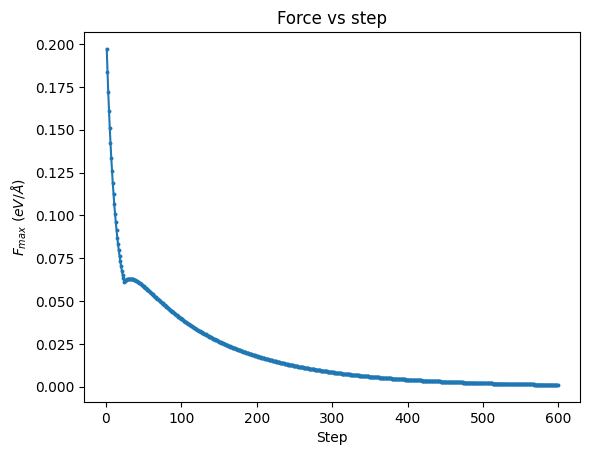

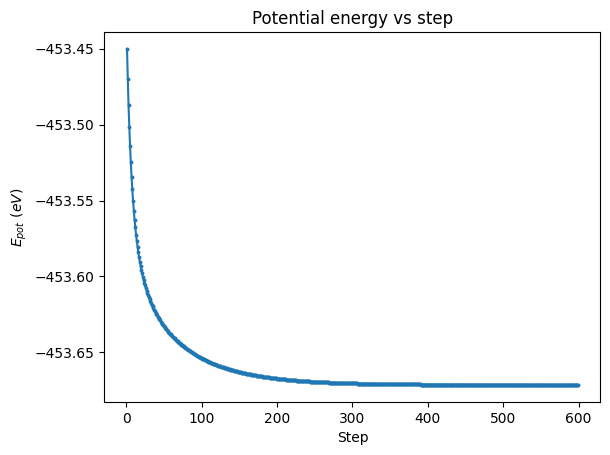

Centro di massa iniziale calcolato in: [7.2807 7.2807 7.2807]
L'atomo più vicino al CM è l'indice: 134 (distanza: 1.7963 A)
Check initial velocities:
 Temperature (T , T' , T'_check)  50 46.72018195990713 50.00000000000001
Initial potential energy =  -453.67140317708237
Initial kinetic energy =  1.6547444626389727
Initial total energy =  -452.0166587144434

 --------------------------------------------------------------- 

1 35.82638519656912 -451.95716286755385
100 25.16083986474707 -451.9487975041441
200 25.039859331776398 -451.9394144792116
300 25.24997777806787 -451.94217016011646
400 25.874285825149393 -451.9487434657576
500 24.47723114663016 -451.9393331579939
Simulazione completata. Dati salvati in Esercizio 1/Risultati/Risultati_MD_poly_steepest_NOpbc_traj2_10ps_50K_19.0fs_600step.dat


In [ ]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_pol
from m_force import calc_force_pol
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol2
from poly7 import poly7

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a256.txt"

# Parametri fisici
epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 50
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 19 * 10**(-15)
nMD = 600
cc = np.sqrt(3 * k_B * temp / mass)

results_dir1 = os.path.join('Esercizio 1','Risultati')
results_dir2 = os.path.join('Esercizio 1','Posizioni','steepest')
# Mi assicuro che la cartella esista per evitare errori
os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir2, exist_ok=True) 


base_filename1 = f'Risultati_MD_poly_steepest_NOpbc_traj2_10ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir1, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                        LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

# Caricamento Posizioni
pos,natoms = read_pos(filename)

# Minimizzazione iniziale
nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
pos = steepest_desc_pol2(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs)

# --- IDENTIFICAZIONE ATOMO CENTRALE ---
# 1. Trovo il CM geometrico della configurazione minimizzata
cm_initial = np.mean(pos, axis=0)

# 2. Calcolo la distanza quadra di ogni atomo dal CM
# (evito la radice quadrata sqrt per efficienza, il minimo è lo stesso)
dist_sq = np.sum((pos - cm_initial)**2, axis=1)

# 3. Trovo l'indice dell'atomo con la distanza minima
idx_central = np.argmin(dist_sq)

print(f"Centro di massa iniziale calcolato in: {cm_initial}")
print(f"L'atomo più vicino al CM è l'indice: {idx_central} (distanza: {np.sqrt(dist_sq[idx_central]):.4f} A)")
# ----------------------------------------------------------

nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
force = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
E_pot_in = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

# Inizializzazione Velocità
vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_CM = np.zeros((nMD,3))
traj_ver = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2

    traj_CM[iMD, :] = pos[idx_central, :]
    traj_ver[iMD, :] = pos[1, :]

    nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
    force_new = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
    
    E_pot = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_CM[iMD,0]} \t {traj_CM[iMD,1]} \t {traj_CM[iMD,2]} \t  {traj_ver[iMD,0]} \t {traj_ver[iMD,1]} \t {traj_ver[iMD,2]} \n")
    
    if(iMD % 100 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        base_filename2 = 'Posizioni poly_steepest_NOpbc '+ str(temp_ini) + 'K step ' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir2, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() 
    
file1.close()
print(f"Simulazione completata. Dati salvati in {outputname1}")

Steepest descent + PBC + NO adatom + traj CM

Max force and step:  0.0009964270360717307 454


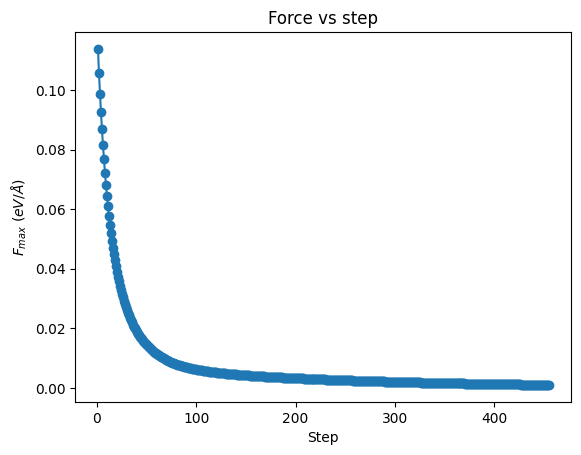

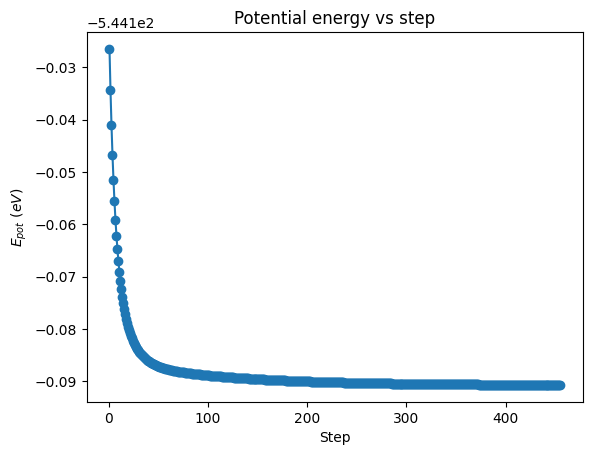

Centro di massa iniziale calcolato in: [7.2807 7.2807 7.2807]
L'atomo più vicino al CM è l'indice: 134 (distanza: 1.8013 A)
Check initial velocities:
 Temperature (T , T' , T'_check)  50 46.72018195990713 50.00000000000001
Initial potential energy =  -544.1906663339012
Initial kinetic energy =  1.6547444626389727
Initial total energy =  -542.5359218712622

 --------------------------------------------------------------- 

1 33.29138685660736 -542.4598182166944
10 25.77413062224046 -542.4559196060134
20 25.650789637583877 -542.445628821349
30 24.79192242744575 -542.4454061073045
40 23.33760633753085 -542.4460853727886
50 24.48327408312529 -542.4420646281225
60 22.673807258151577 -542.4417379400412
70 24.227429298382667 -542.4363213456701
80 26.149601164134825 -542.4548900455185
90 28.004554002917097 -542.4612569273901
100 25.206118387839428 -542.4493336250863
110 25.024750150792396 -542.444418483964
120 25.50634133691715 -542.4432127635453
130 22.62474203077094 -542.4424512545589
140 26

In [18]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs_pbc
from m_epot import calc_epot_pol_pbc
from m_force import calc_force_pol_pbc
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol2_pbc
from poly7 import poly7

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a256.txt"

# Parametri fisici
epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 50
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 19 * 10**(-15)
nMD = 600
Lx = Ly = 16.6416
Lz = 100
cc = np.sqrt(3 * k_B * temp / mass)


results_dir1 = os.path.join('Esercizio 1','Risultati')
results_dir2 = os.path.join('Esercizio 1','Posizioni','steepest')
# Mi assicuro che la cartella esista per evitare errori
os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir2, exist_ok=True) 


base_filename1 = f'Risultati_MD_poly_steepest_SIpbc_traj2_10ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir1, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                        LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

# Caricamento Posizioni
pos,natoms = read_pos(filename)

# Minimizzazione iniziale
nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
pos = steepest_desc_pol2_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)

# --- IDENTIFICAZIONE ATOMO CENTRALE ---
# 1. Trovo il CM geometrico della configurazione minimizzata
cm_initial = np.mean(pos, axis=0)

# 2. Calcolo la distanza quadra di ogni atomo dal CM
# (evito la radice quadrata sqrt per efficienza, il minimo è lo stesso)
dist_sq = np.sum((pos - cm_initial)**2, axis=1)

# 3. Trovo l'indice dell'atomo con la distanza minima
idx_central = np.argmin(dist_sq)

print(f"Centro di massa iniziale calcolato in: {cm_initial}")
print(f"L'atomo più vicino al CM è l'indice: {idx_central} (distanza: {np.sqrt(dist_sq[idx_central]):.4f} A)")
# ----------------------------------------------------------

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
force = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
E_pot_in = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

# Inizializzazione Velocità
vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_CM = np.zeros((nMD,3))
traj_ver = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2

    traj_CM[iMD, :] = pos[idx_central, :]
    traj_ver[iMD, :] = pos[1, :]

    nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
    force_new = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
    
    E_pot = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_CM[iMD,0]} \t {traj_CM[iMD,1]} \t {traj_CM[iMD,2]} \t  {traj_ver[iMD,0]} \t {traj_ver[iMD,1]} \t {traj_ver[iMD,2]} \n")
    
    if(iMD % 10 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        base_filename2 = 'Posizioni poly_steepest_SIpbc '+ str(temp_ini) + 'K step ' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir2, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() 
    
file1.close()
print(f"Simulazione completata. Dati salvati in {outputname1}")

CM calcolato ad ogni step (punto fermo)

In [ ]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_epot import calc_epot_pol
from m_force import calc_force_pol
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol2
from poly7 import poly7

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a256.txt"

# Parametri fisici
epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 2000
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 2 * 10**(-15)
nMD = 5000
cc = np.sqrt(3 * k_B * temp / mass)

results_dir = 'Esercizio 1'
base_filename1 = f'Risultati_MD_poly_steepest_NOpbc_traj_10ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                        LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

# Caricamento Posizioni
pos,natoms = read_pos(filename)

# Minimizzazione iniziale
nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
pos = steepest_desc_pol2(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs)

nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
force = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
E_pot_in = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

# Inizializzazione Velocità
vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_CM = np.zeros((nMD,3))
traj_ver = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2

    traj_CM[iMD, 0] = np.mean(pos[:, 0])
    traj_CM[iMD, 1] = np.mean(pos[:, 1])
    traj_CM[iMD, 2] = np.mean(pos[:, 2])

    traj_ver[iMD, :] = pos[1, :]

    nnbrs,whichnbr = calc_nbrs(natoms,pos,cutoff)
    force_new = calc_force_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)
    
    E_pot = calc_epot_pol(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_CM[iMD,0]} \t {traj_CM[iMD,1]} \t {traj_CM[iMD,2]} \t  {traj_ver[iMD,0]} \t {traj_ver[iMD,1]} \t {traj_ver[iMD,2]} \n")
    
    if(iMD % 100 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        ''' base_filename2 = 'Posizioni poly_steepest_pbc_adatom lezione 15 '+ str(temp_ini) + 'K step ' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() '''
    
file1.close()
print(f"Simulazione completata. Dati salvati in {outputname1}")

Plot before and after steepest descent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

##### BEFORE STEEPEST DESCENT ######

results_dir = os.path.join("Esercizio 1")
base_filename = f'Risultati_MD_poly_NOsteepest_2000K_2.0fs_5000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step1 = data[:,0]
time = step1 * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temper1 = data[:,1]
Epot1 = data[:,2]
Ekin1 = data[:,3]
Etot1 = data[:,4]

n = 1
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step1)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temper1[i]
        temp2 += temper1[i]**2
        avgE_pot += Epot1[i]
        E2_pot += Epot1[i]**2
        avgE_kin += Ekin1[i]
        E2_kin += Ekin1[i]**2
        avgE_tot += Etot1[i]
        E2_tot += Etot1[i]**2
        
avgE_pot1 = avgE_pot / n
E2_pot1 = E2_pot / n
deltaE_pot1 = np.sqrt(E2_pot1 - avgE_pot1**2)

avgE_kin1 = avgE_kin / n
E2_kin1 = E2_kin / n
deltaE_kin1 = np.sqrt(E2_kin1 - avgE_kin1**2)

avgE_tot1 = avgE_tot / n
E2_tot1 = E2_tot / n
deltaE_tot1 = np.sqrt(E2_tot1 - avgE_tot1**2)

avgT1 = avgT / n
temp21 = temp2 / n
deltaT1 = np.sqrt(temp21 - avgT1**2)

print("Potential energy fluctuations", deltaE_pot1 / avgE_pot1)
print("Kinetic energy fluctuations", deltaE_kin1 / avgE_kin1)
print("Total energy fluctuations", deltaE_tot1 / avgE_tot1)
print("Temperature fluctuations", deltaT1 / avgT1)


###### AFTER STEEPEST DESCENT ######

results_dir = os.path.join("Esercizio 1")
base_filename = f'Risultati_MD_poly_steepest_10ps_2000K_2.0fs_5000step.dat'
#base_filename = f'Risultati_MD_poly_steepest_NOpbc_traj_10ps_500K_6.0fs_1700step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step2 = data[:,0]
time = step2 * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temper2 = data[:,1]
Epot2 = data[:,2]
Ekin2 = data[:,3]
Etot2 = data[:,4]

n = 1
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step2)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temper2[i]
        temp2 += temper2[i]**2
        avgE_pot += Epot2[i]
        E2_pot += Epot2[i]**2
        avgE_kin += Ekin2[i]
        E2_kin += Ekin2[i]**2
        avgE_tot += Etot2[i]
        E2_tot += Etot2[i]**2
        
avgE_pot2 = avgE_pot / n
E2_pot2 = E2_pot / n
deltaE_pot2 = np.sqrt(E2_pot2 - avgE_pot2**2)

avgE_kin2 = avgE_kin / n
E2_kin2 = E2_kin / n
deltaE_kin2 = np.sqrt(E2_kin2 - avgE_kin2**2)

avgE_tot2 = avgE_tot / n
E2_tot2 = E2_tot / n
deltaE_tot2 = np.sqrt(E2_tot2 - avgE_tot2**2)

avgT2 = avgT / n
temp22 = temp2 / n
deltaT2 = np.sqrt(temp22 - avgT2**2)

print("Potential energy fluctuations", deltaE_pot2 / avgE_pot2)
print("Kinetic energy fluctuations", deltaE_kin2 / avgE_kin2)
print("Total energy fluctuations", deltaE_tot2 / avgE_tot2)
print("Temperature fluctuations", deltaT2 / avgT2)




# PLOT TEMPERATURA 
label_T1 = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT1:.3f}\\pm{deltaT1:.3f}~\\mathrm{{K}}$'
plt.plot(step1*dt,temper1,label=label_T1, color="r")
label_T2 = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT2:.3f}\\pm{deltaT2:.3f}~\\mathrm{{K}}$'
plt.plot(step2*dt,temper2,label=label_T2, color="b")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

'''# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()
'''

Punto 4: Infinite crystal slab + adatom

In [ ]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_nbrs import calc_nbrs_pbc
from m_epot import calc_epot_pol
from m_epot import calc_epot_pol_pbc
from m_force import calc_force_pol
from m_force import calc_force_pol_pbc
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol
from steepest_descent import steepest_desc_pol2
from steepest_descent import steepest_desc_pol2_pbc
from poly7 import poly7 
from numba import jit 

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a256.txt"

epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 1700
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 2 * 10**(-15)
nMD = 150000
cc = np.sqrt(3 * k_B * temp / mass)
Lx = Ly = 16.6416
Lz = 100

results_dir = 'Esercizio 1'
base_filename1 = f'Risultati_MD_poly_steepest_pbc_adatom_300ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                             LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

pos,natoms = read_pos(filename)
adatom_x = Lx / 2
adatom_y = Ly / 2
adatom_z = np.max(pos[:,2]) + 2.4
adatom = np.array([adatom_x , adatom_y , adatom_z])
pos = np.vstack([pos , adatom])
natoms += 1

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
pos = steepest_desc_pol2_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
force = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
E_pot_in = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_adatom = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2
    
    nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
    force_new = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
    
    E_pot = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    traj_adatom[iMD,0] = pos[-1,0]
    traj_adatom[iMD,1] = pos[-1,1]
    traj_adatom[iMD,2] = pos[-1,2]

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_adatom[iMD,0]} \t {traj_adatom[iMD,1]} \t {traj_adatom[iMD,2]}\n")

    
    if(iMD % 100 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        ''' base_filename2 = 'Posizioni poly_steepest_pbc_adatom lezione 15 '+ str(temp_ini) + 'K step ' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() '''
    

file1.close()




Punto 5: fcc orientazione 111

In [ ]:
import numpy as np
import os
from m_readinput import read_pos
from m_nbrs import calc_nbrs
from m_nbrs import calc_nbrs_pbc
from m_epot import calc_epot_pol
from m_epot import calc_epot_pol_pbc
from m_force import calc_force_pol
from m_force import calc_force_pol_pbc
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol
from steepest_descent import steepest_desc_pol2
from steepest_descent import steepest_desc_pol2_pbc
from poly7 import poly7 
from numba import jit 

myseed=16324478
np.random.seed(myseed)

filename = "fcc111a336+1.txt"

epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
temp = 1700
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 2 * 10**(-15)
nMD = 150000
cc = np.sqrt(3 * k_B * temp / mass)
Lx = Ly = 20.3817
Lz = 100

results_dir = 'Esercizio 1'
base_filename1 = f'Risultati_MD_poly_steepest_pbc_adatom_111_300ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                             LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

pos,natoms = read_pos(filename)

'''adatom_x = Lx / 2
adatom_y = Ly / 2
adatom_z = np.max(pos[:,2]) + 2.4
adatom = np.array([adatom_x , adatom_y , adatom_z])
pos = np.vstack([pos , adatom])
natoms += 1 '''

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
pos = steepest_desc_pol2_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
force = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
E_pot_in = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))
traj_adatom = np.zeros((nMD,3))

file1 = open(outputname1, "w")

for iMD in range(1,nMD):
    time = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2
    
    nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,cutoff,Lx,Ly,Lz)
    force_new = calc_force_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)
    
    E_pot = calc_epot_pol_pbc(natoms,pos,epsilon,sigma,nnbrs,whichnbr,rpoly,poly_coeffs,Lx,Ly,Lz)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    traj_adatom[iMD,0] = pos[-1,0]
    traj_adatom[iMD,1] = pos[-1,1]
    traj_adatom[iMD,2] = pos[-1,2]

    file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \t {traj_adatom[iMD,0]} \t {traj_adatom[iMD,1]} \t {traj_adatom[iMD,2]} \n")

    
    if(iMD % 100 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        base_filename2 = 'Posizioni poly_steepest_pbc_adatom_111 lezione 15 '+ str(temp_ini) + 'K step ' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() 
    

file1.close()




Plot senza traiettorie

Potential energy fluctuations -0.0020707773471397395
Kinetic energy fluctuations 0.03790227990637666
Total energy fluctuations -3.548848125106413e-06
Temperature fluctuations 0.03790227990605207


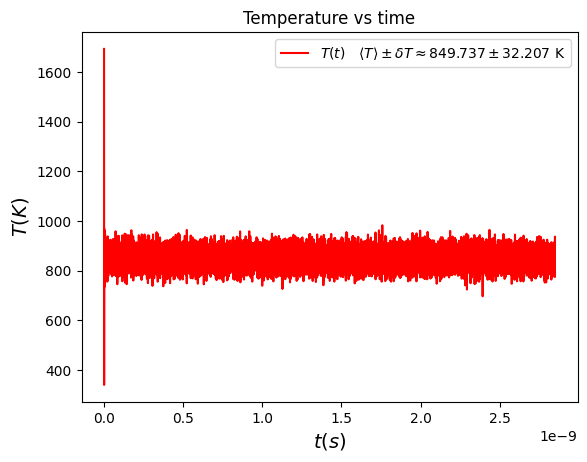

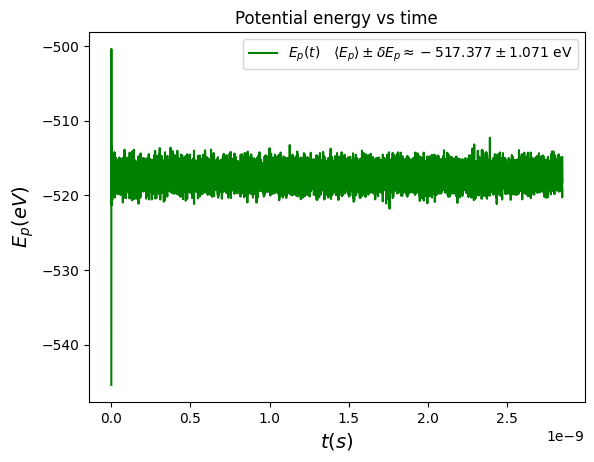

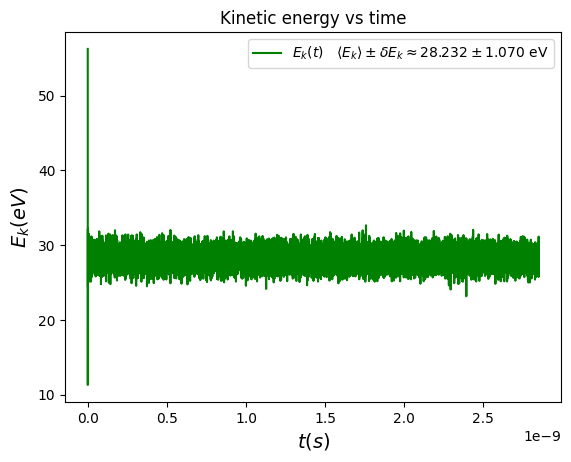

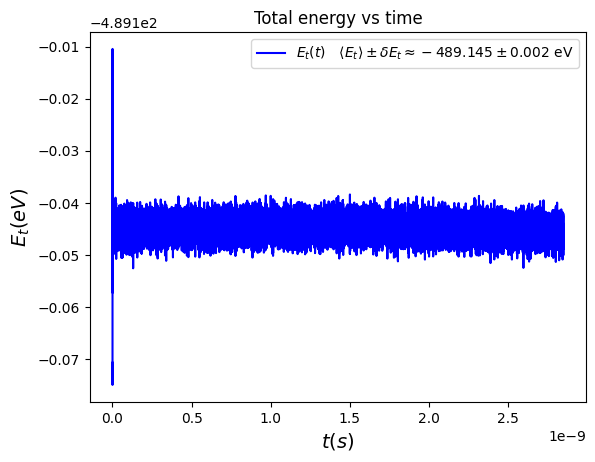

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = 'Esercizio 1'
#base_filename = f'Risultati_MD_poly_50K_19fs_5000step.dat'
base_filename = f'Risultati_MD_poly_steepest_pbc_adatom_300ps_1700K_2.0fs_150000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 19 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)


print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()





Plot + traiettorie

--- Inizio Plotting Traiettorie ---
Potential energy fluctuations -0.003044918340899943
Kinetic energy fluctuations 0.041987879243715207
Total energy fluctuations -4.270788997571826e-06
Temperature fluctuations 0.04198787924368079


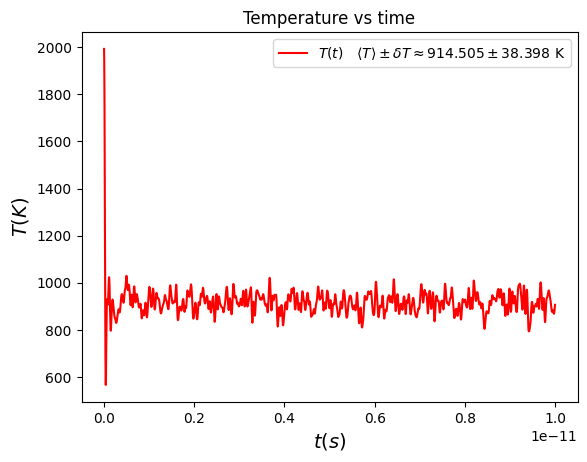

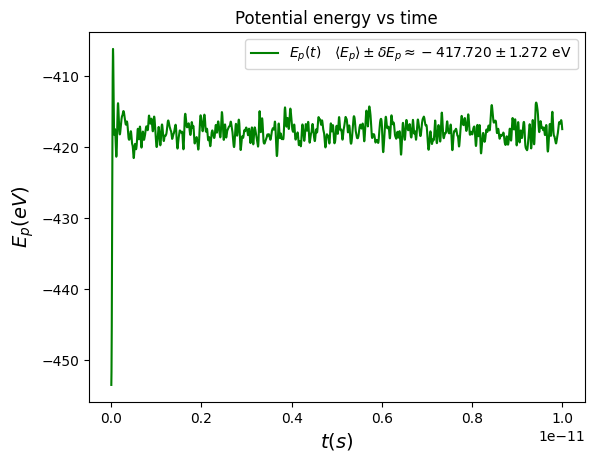

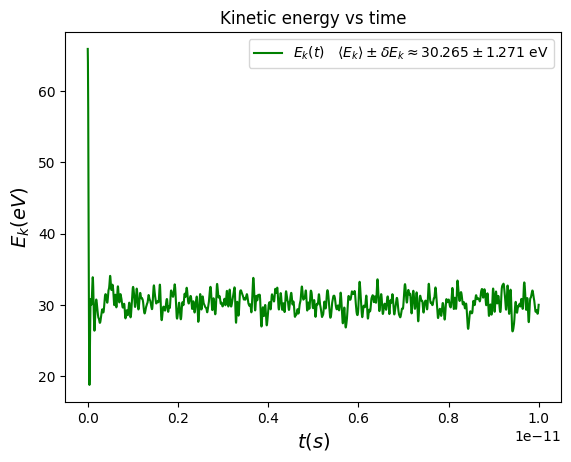

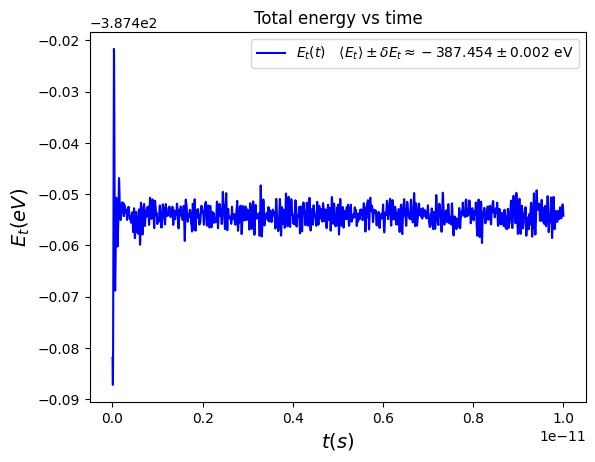

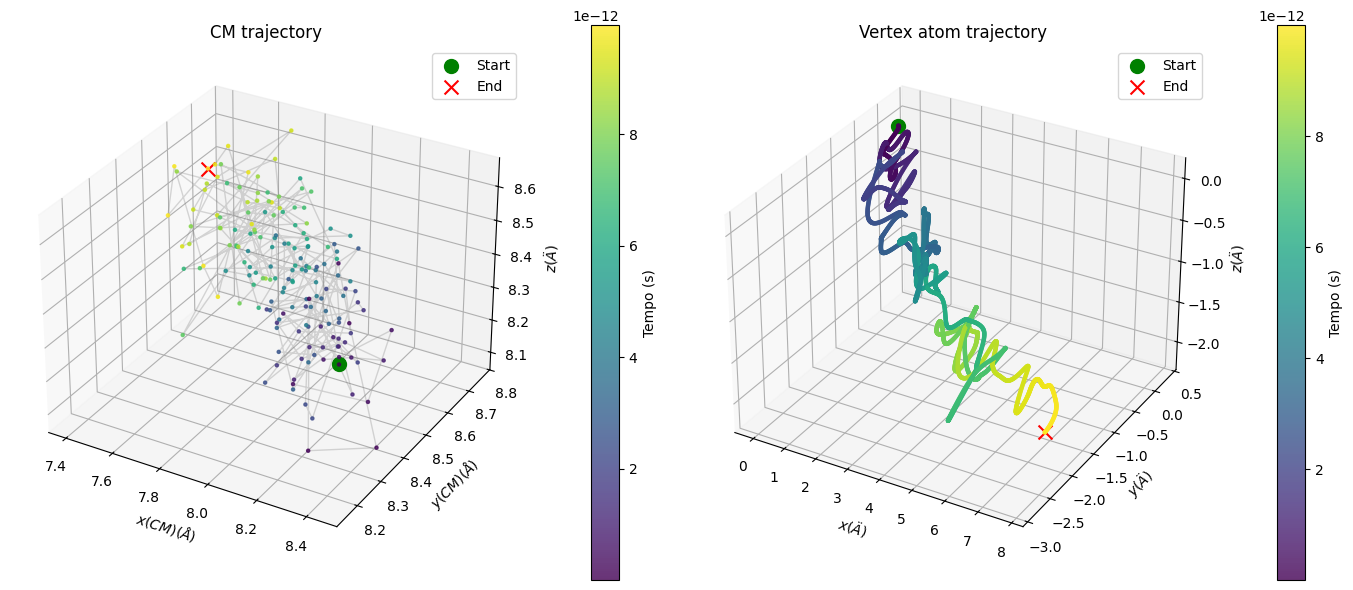

'fig = plt.figure()\nax1 = fig.add_subplot(projection=\'3d\')\nfor iMD in range(0,nMD-1):\n    ax1.scatter(xCM[iMD],yCM[iMD],zCM[iMD])\n\nax1.set_xlabel(\'xCM\')\nax1.set_ylabel(\'yCM\')\nax1.set_zlabel(\'zCM\')\nplt.show()\n\nplt.figure()\nplt.scatter(xCM, yCM, zCM, color="b", lw=1)\n# punti ogni tot passi\n\nplt.title("Trajectory of CM")\nplt.xlabel(\'$x (Å)$\', fontsize=14)\nplt.ylabel(\'$y (Å)$\', fontsize=14)\n\nfig = plt.figure()\nax2 = fig.add_subplot(projection=\'3d\')\nfor iMD in range(0,nMD-1):\n    ax2.scatter(xVer[iMD],yVer[iMD],zVer[iMD], color=\'b\')\n\nax2.set_xlabel(\'xVer\')\nax2.set_ylabel(\'yVer\')\nax2.set_zlabel(\'zVer\')\nplt.show() '

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# ... (tutto il tuo codice precedente per caricamento dati e calcolo statistiche) ...

print("--- Inizio Plotting Traiettorie ---")

def plot_trajectory_3d(ax, x, y, z, time_array, title, arrow_freq=20):
    """
    Plotta una traiettoria 3D con color coding temporale e frecce di direzione.
    arrow_freq: ogni quanti step disegnare una freccia.
    """
    # 1. Linea continua sottile per vedere il percorso
    ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=1)

    # 2. Scatter plot colorato in base al tempo
    # Usiamo 'viridis' o 'plasma' per alto contrasto
    sc = ax.scatter(x, y, z, c=time_array, cmap='viridis', s=5, alpha=0.8)
    
    # 3. Aggiunta Frecce (Quiver) per la direzione
    # Calcoliamo i vettori direzione (differenza tra posizioni successive)
    u = np.diff(x)
    v = np.diff(y)
    w = np.diff(z)
    
    # Selezioniamo solo alcuni punti per non affollare il grafico (slicing)
    # Partiamo da 0, fino alla fine, con passo 'arrow_freq'
    idx = np.arange(0, len(x)-1, arrow_freq)
    
    # Normalizziamo la lunghezza delle frecce per renderle visibili uniformemente
    norm = np.sqrt(u[idx]**2 + v[idx]**2 + w[idx]**2)
    # Evitiamo divisioni per zero se l'atomo è fermo
    norm[norm == 0] = 1.0 
    
    # Plottiamo le frecce. length determina la lunghezza visiva
    '''ax.quiver(x[idx], y[idx], z[idx], 
              u[idx]/norm, v[idx]/norm, w[idx]/norm, 
              color='black', length=1.0, normalize=True, alpha=0.6, arrow_length_ratio=0.3)'''

    # 4. Marker Inizio e Fine
    ax.scatter(x[0], y[0], z[0], color='green', s=100, marker='o', label='Start')
    ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, marker='x', label='End')

    ax.set_xlabel('$x (Ä)$')
    ax.set_ylabel('$y (Ä)$')
    ax.set_zlabel('$z (Ä)$')
    ax.set_title(title)
    
    # Colorbar per indicare il tempo
    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label('Tempo (s)')
    ax.legend()


#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
BASE_PATH = os.path.dirname(os.path.abspath('Codici Esercizio 1.ipynb'))
results_dir = os.path.join(BASE_PATH,'Esercizio 1','Risultati')
base_filename = f'Risultati_MD_poly_steepest_NOpbc_traj2_10ps_2000K_2.0fs_5000step.dat'
#base_filename = f'Risultati_MD_poly_NOsteepest_trajCM_2000K_2.0fs_5000step.dat'
#base_filename = f'Risultati_MD_poly_steepest_pbc_adatom_111_300ps_1700K_2.0fs_150000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
nMD = 5000
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]
xCM = data[:,5]
yCM = data[:,6]
zCM = data[:,7]
xVer = data[:,8]
yVer = data[:,9]
zVer = data[:,10]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)


print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()


# Creiamo una figura con due subplot 3D affiancati
fig = plt.figure(figsize=(14, 6))

# --- Plot Centro di Massa (CM) ---
ax1 = fig.add_subplot(121, projection='3d')
plot_trajectory_3d(ax1, xCM[0::30], yCM[0::30], zCM[0::30], time[0::30], 
                   f"CM trajectory")
plt.xlabel('$x(CM) (Å)$', fontsize=10)
plt.ylabel('$y(CM) (Å)$', fontsize=10)


# --- Plot Vertice (Adatom/Atomo singolo) ---
ax2 = fig.add_subplot(122, projection='3d')
plot_trajectory_3d(ax2, xVer, yVer, zVer, time, 
                   "Vertex atom trajectory")

plt.tight_layout()
plt.show()




# PLOT traiettoria adatom
#label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
'''X = np.arange(min(adatom_traj[:,0])-2, max(adatom_traj[:,0])+2)
Y = np.arange(min(adatom_traj[:,1])-2, max(adatom_traj[:,1])+2)
X, Y = np.meshgrid(X, Y)
Z = np.array([])'''

'''plt.plot(adatom_x,adatom_y, color="b")
plt.title("Trajectory of adatom")
plt.xlabel('$x (Å)$', fontsize=14)
plt.ylabel('$y (Å)$', fontsize=14)
plt.legend()
plt.show()'''


'''fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')
for iMD in range(0,nMD-1):
    ax1.scatter(xCM[iMD],yCM[iMD],zCM[iMD])

ax1.set_xlabel('xCM')
ax1.set_ylabel('yCM')
ax1.set_zlabel('zCM')
plt.show()

plt.figure()
plt.scatter(xCM, yCM, zCM, color="b", lw=1)
# punti ogni tot passi

plt.title("Trajectory of CM")
plt.xlabel('$x (Å)$', fontsize=14)
plt.ylabel('$y (Å)$', fontsize=14)

fig = plt.figure()
ax2 = fig.add_subplot(projection='3d')
for iMD in range(0,nMD-1):
    ax2.scatter(xVer[iMD],yVer[iMD],zVer[iMD], color='b')

ax2.set_xlabel('xVer')
ax2.set_ylabel('yVer')
ax2.set_zlabel('zVer')
plt.show() '''




Verlet cages + Andersen thermostat

Max force and step:  4.2401327234757586e-14 0


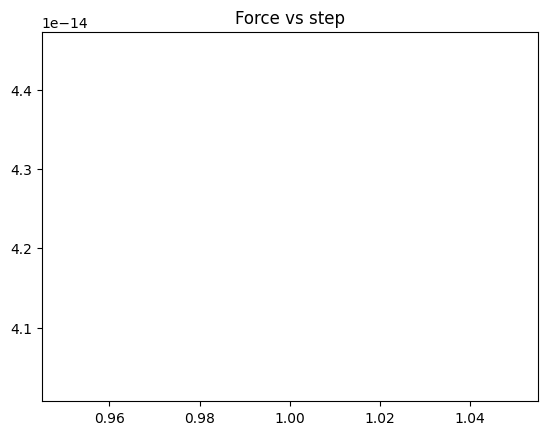

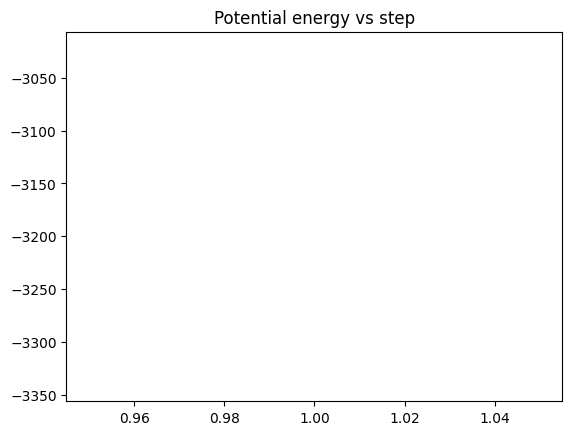

Initial temperatue =  2000
Initial potential energy =  -3181.285031179057
Initial kinetic energy =  370.458743639651
Initial total energy =  -2810.826287539406

 --------------------------------------------------------------- 

1 2078.8150487281373 -2810.8254594307737
100 1201.9042210942405 -2783.9226191671805
200 1218.9305147205014 -2751.2273257302954
300 1281.6972555053824 -2720.2237089435334
400 1446.4167550757954 -2696.634967765397
500 1423.737595060016 -2681.234938660196
600 1538.1700978424888 -2647.9255919835878
700 1582.0794264836877 -2631.1390141233396
800 1569.3248735886505 -2617.138946240698
900 1699.1016454843777 -2602.297075934727
1000 1698.6518438316018 -2590.1002549884456
1100 1750.1726872693291 -2582.149416585744
1200 1715.9582743751237 -2577.3610901852194
1300 1785.7157890053854 -2571.426896133058
1400 1786.301081151952 -2568.356615585122
1500 1806.8186473626351 -2559.5597607424456
1600 1845.4002039113489 -2549.5927280342366
1700 1831.7700065423596 -2535.7880912427163
1

In [7]:
import numpy as np
import os
import time
from m_readinput import read_pos
from m_nbrs import calc_nbrs_pbc
from m_epot import calc_epot_pol_pbc_cages
from m_force import calc_force_pol_pbc_cages
from m_vel import calc_vel
from steepest_descent import steepest_desc_pol2_pbc_cages
from poly7 import poly7 

myseed=16324478
np.random.seed(myseed)

filename = "fcc100a1372.txt"

epsilon = 0.345
sigma = 2.644
cutoff = 4.5
rpoly = 4.2
rverlet = cutoff + 0.5
temp = 2000
temp_ini = temp
k_B = 1 / 11603
mass = 108 * 1.66*10**(-27) / 16
dt = 2 * 10**(-15)
nu = 1 * 10**(12)
nMD = 5000
cc = np.sqrt(3 * k_B * temp / mass)
Lx = Ly = Lz = 29.1228
#Lx(256)=16.6416, Lx(500)=20.802, Lx(864)=24.9624, Lx(1372)=29.1228, Lz(2048)=33.2832
sigma_andersen = np.sqrt(k_B * temp_ini / mass)



BASE_PATH = os.path.dirname(os.path.abspath('MS_coding_16.ipynb'))
results_dir1 = os.path.join(BASE_PATH, 'Esercizio 1', 'Risultati')
results_dir2 = os.path.join(BASE_PATH, 'Esercizio 1', 'Posizioni', 'Verlet')
os.makedirs(results_dir1, exist_ok=True)
os.makedirs(results_dir2, exist_ok=True)
base_filename1 = f'Risultati_MD_256_verletcages_Andersen_10ps_{temp}K_{dt*1e15}fs_{nMD}step.dat'
outputname1 = os.path.join(results_dir1, base_filename1)

LJpoly = poly7(epsilon, sigma, cutoff, rpoly)
poly_coeffs = np.array([LJpoly.A, LJpoly.B, LJpoly.C, LJpoly.D, 
                             LJpoly.E, LJpoly.F, LJpoly.G, LJpoly.H], dtype=np.float64)

pos,natoms = read_pos(filename)
nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,rverlet,Lx,Ly,Lz)
pos = steepest_desc_pol2_pbc_cages(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)
ref = pos.copy()

nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,rverlet,Lx,Ly,Lz)
force = calc_force_pol_pbc_cages(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)
E_pot_in = calc_epot_pol_pbc_cages(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)

#vel, E_kin_in = calc_vel(cc,natoms,myseed,temp)
vel = np.random.normal(0, sigma_andersen, (natoms,3))
E_kin_in = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

print("Initial temperatue = ", temp_ini)
print("Initial potential energy = ", E_pot_in)
print("Initial kinetic energy = ", E_kin_in)
print("Initial total energy = ", E_pot_in + E_kin_in)
print("\n --------------------------------------------------------------- \n")

force_new = np.zeros((natoms,3))

#file1 = open(outputname1, "w")

time_start = time.time()

for iMD in range(1,nMD):
    time_sim = iMD * dt

    pos = pos + vel*dt + 0.5 * (force / mass) * dt **2
    
    diff = pos - ref
    diff[:,0] = diff[:,0] - Lx*np.round(diff[:,0]/Lx)
    diff[:,1] = diff[:,1] - Ly*np.round(diff[:,1]/Ly)
    diff[:,2] = diff[:,2] - Lz*np.round(diff[:,2]/Lz)
    dist = np.sqrt(diff[:,0]**2 + diff[:,1]**2 + diff[:,2]**2)

    if np.max(dist) > (rverlet - cutoff) / 2:
        nnbrs,whichnbr = calc_nbrs_pbc(natoms,pos,rverlet,Lx,Ly,Lz)
        ref = pos.copy()
    
    force_new = calc_force_pol_pbc_cages(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)
    
    E_pot = calc_epot_pol_pbc_cages(natoms,pos,epsilon,sigma,nnbrs,whichnbr,cutoff,rpoly,poly_coeffs,Lx,Ly,Lz)

    vel = vel + 0.5 * (force + force_new)/mass * dt
    
    E_kin = 0.5 * mass * (np.sum(vel[:,0]**2)+np.sum(vel[:,1]**2)+np.sum(vel[:,2]**2))

    force = force_new

    collision_mask = np.random.rand(natoms) < (nu * dt)
    n_collisions = np.sum(collision_mask)
    if n_collisions > 0:
        vel[collision_mask, :] = np.random.normal(0, sigma_andersen, (n_collisions,3))
    
    temp = 2/3 * E_kin / (natoms * k_B)
    E_tot = E_pot + E_kin

    #file1.write(f"{iMD} \t {temp} \t {E_pot} \t {E_kin} \t {E_tot} \n")

    
    if(iMD % 100 == 0) or iMD == 1:

        print(iMD,temp,E_tot)

        base_filename2 = 'Posizioni VerletCages_Andersen_'+ str(natoms)+'atoms_' + str(temp_ini) + 'K_step' + str(iMD) + '.xyz'
        outputname2 = os.path.join(results_dir2, base_filename2)
        file2 = open(outputname2,'w')
        file2.write(f"{natoms} \n {iMD*dt}\n")
        for i in range(0,natoms):
            file2.write(f"{pos[i,0]} \t {pos[i,1]} \t {pos[i,2]} \n")
        file2.close() 
    

#file1.close()

time_stop = time.time()
time_per_step = (time_stop - time_start) / (nMD -1)
print('Time per step = ', time_per_step)


Plot Verlet + Andersen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#inputname = f'Risultati_MD_poly_50K_1.0fs_5000step.dat'
results_dir = 'Esercizio 1'
base_filename = f'Risultati_MD_256_verletcages_Andersen_10ps_2000K_2.0fs_5000step.dat'
#base_filename = f'Risultati_MD_poly_steepest_pbc_adatom_111_300ps_1700K_2.0fs_150000step.dat'
filename = os.path.join(results_dir, base_filename)
data = np.loadtxt(filename)

dt = 2 * 10**(-15)
step = data[:,0]
time = step * dt
time_end = time[-1]
thTIME = 3 * 10**(-12)

temp = data[:,1]
Epot = data[:,2]
Ekin = data[:,3]
Etot = data[:,4]

#adatom_x = data[:,5]
#adatom_y = data[:,6]

n = 0
avgE_tot = 0
E2_tot = 0
avgE_pot = 0
E2_pot = 0
avgE_kin = 0
E2_kin = 0
avgT = 0
temp2 = 0

for i in range(0,len(step)):
    t = i * dt

    if(t > thTIME):
        n += 1
        avgT += temp[i]
        temp2 += temp[i]**2
        avgE_pot += Epot[i]
        E2_pot += Epot[i]**2
        avgE_kin += Ekin[i]
        E2_kin += Ekin[i]**2
        avgE_tot += Etot[i]
        E2_tot += Etot[i]**2
        
avgE_pot = avgE_pot / n
E2_pot = E2_pot / n
deltaE_pot = np.sqrt(E2_pot - avgE_pot**2)

avgE_kin = avgE_kin / n
E2_kin = E2_kin / n
deltaE_kin = np.sqrt(E2_kin - avgE_kin**2)

avgE_tot = avgE_tot / n
E2_tot = E2_tot / n
deltaE_tot = np.sqrt(E2_tot - avgE_tot**2)

avgT = avgT / n
temp2 = temp2 / n
deltaT = np.sqrt(temp2 - avgT**2)


print("Potential energy fluctuations", deltaE_pot / avgE_pot)
print("Kinetic energy fluctuations", deltaE_kin / avgE_kin)
print("Total energy fluctuations", deltaE_tot / avgE_tot)
print("Temperature fluctuations", deltaT / avgT)

# PLOT TEMPERATURA 
label_T = f'$T(t)\\quad \\langle T \\rangle \\pm \\delta T \\approx {avgT:.3f}\\pm{deltaT:.3f}~\\mathrm{{K}}$'
plt.plot(step*dt,temp,label=label_T, color="r")
plt.title("Temperature vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$T(K)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA POTENZIALE
label_Ep = f'$E_p(t)\\quad\\langle E_p\\rangle\\pm\\delta E_p \\approx {avgE_pot:.3f}\\pm{deltaE_pot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Epot, label=label_Ep, color="g")
plt.title("Potential energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_p(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA CINETICA
label_Ek = f'$E_k(t)\\quad\\langle E_k\\rangle\\pm\\delta E_k \\approx {avgE_kin:.3f}\\pm{deltaE_kin:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Ekin, label=label_Ek, color="g")
plt.title("Kinetic energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_k(eV)$', fontsize=14)
plt.legend()
plt.show()

# PLOT ENERGIA TOTALE
label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'
plt.plot(step*dt, Etot, label=label_Et, color="b")
plt.title("Total energy vs time")
plt.xlabel('$t(s)$', fontsize=14)
plt.ylabel('$E_t(eV)$', fontsize=14)
plt.legend()
plt.show()

''# PLOT traiettoria adatom
#label_Et = f'$E_t(t)\\quad\\langle E_t\\rangle\\pm\\delta E_t \\approx {avgE_tot:.3f}\\pm{deltaE_tot:.3f}~\\mathrm{{eV}}$'


'''plt.figure()
plt.plot(adatom_x, adatom_y, color="b", lw=1)
# punti ogni 500 passi
indices = np.arange(0, len(step), 7000)
plt.scatter(adatom_x[indices], adatom_y[indices], color="k", s=20, zorder=3)

# annota con l'indice di passo (colonna step)
for idx in indices:
    plt.annotate(f"{int(step[idx])}", (adatom_x[idx], adatom_y[idx]),
                 textcoords="offset points", xytext=(5,5), fontsize=8, zorder=4)

plt.title("Trajectory of adatom")
plt.xlabel('$x (Å)$', fontsize=14)
plt.ylabel('$y (Å)$', fontsize=14)
plt.show()'''
